### Installation Instructions

- `brew install graphviz`
- create conda env and activate it
- `conda install -c conda-forge pygraphviz`
- `pip install networkx matplotlib pygambit`
- `ipykernel` etc
- In Gambit do `pip install -e .`

Also installed `pytest`

`python -m pytest test_extensive_display.py -v`

In [1]:
from extensive_display import plot_gambit_tree
import pygambit as gbt

/Users/echalstrey/anaconda3/envs/gbt_pygraphviz/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:1296: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  draw_networkx_edges(G, pos, arrows=arrows, **edge_kwds)
/Users/echalstrey/projects/gambit/doc/tutorials/extensive_display.py:226: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


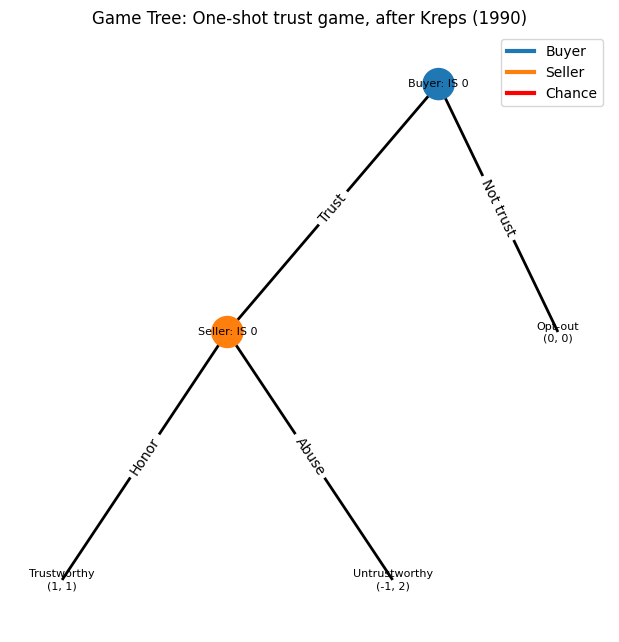

In [2]:
trust_game = gbt.read_efg("games/trust_game.efg")
plot_gambit_tree(trust_game)

In [3]:
type(trust_game)

pygambit.gambit.Game

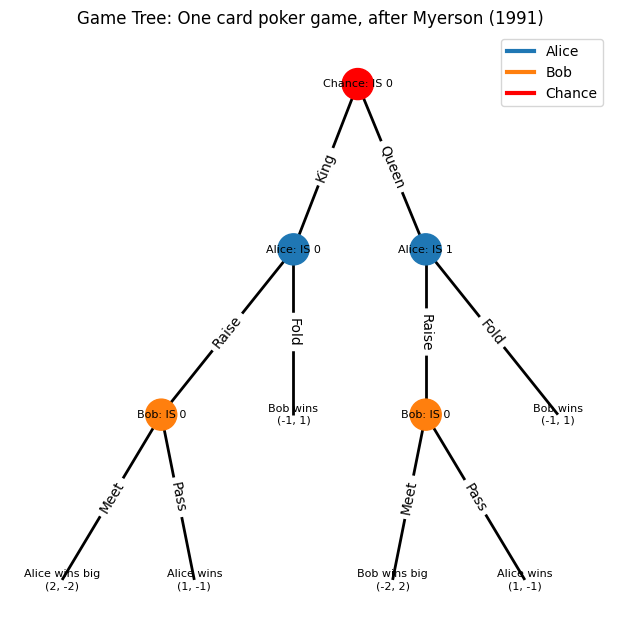

In [4]:
poker_g = gbt.read_efg("../poker.efg")
plot_gambit_tree(poker_g)

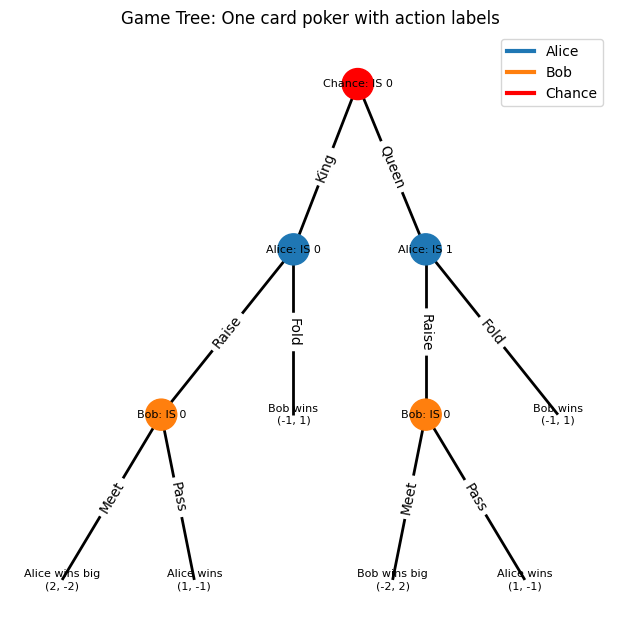

In [5]:
g = gbt.Game.new_tree(players=["Alice", "Bob"], title="One card poker with action labels")
g.append_move(
    g.root,
    player=g.players.chance,
    actions=["King", "Queen"],  # By default, chance actions have equal probabilities
)
for node in g.root.children:
    g.append_move(node, player="Alice", actions=["Raise", "Fold"])
g.append_move(
    g.root.children[0].children[0], player="Bob", actions=["Meet", "Pass"]
)
g.append_infoset(
    g.root.children[1].children[0],
    infoset=g.root.children[0].children[0].infoset,
)
alice_winsbig = g.add_outcome([2, -2], label="Alice wins big")
alice_wins = g.add_outcome([1, -1], label="Alice wins")
bob_winsbig = g.add_outcome([-2, 2], label="Bob wins big")
bob_wins = g.add_outcome([-1, 1], label="Bob wins")

# Alice folds, Bob wins small
g.set_outcome(g.root.children[0].children[1], bob_wins)
g.set_outcome(g.root.children[1].children[1], bob_wins)

# Bob sees Alice raise and calls, correctly believing she is bluffing, Bob wins big
g.set_outcome(g.root.children[1].children[0].children[0], bob_winsbig)

# Bob sees Alice raise and calls, incorrectly believing she is bluffing, Alice wins big
g.set_outcome(g.root.children[0].children[0].children[0], alice_winsbig)

# Bob does not call Alice's raise, Alice wins small
g.set_outcome(g.root.children[0].children[0].children[1], alice_wins)
g.set_outcome(g.root.children[1].children[0].children[1], alice_wins)

plot_gambit_tree(g)

In [6]:
g.root.infoset

Infoset(player=ChancePlayer(game=Game(title='One card poker with action labels')), number=0)

In [7]:
node = g.root.children[0]
f"{node.infoset.player.label}: {node.infoset.number}"

'Alice: 0'

In [8]:
node = g.root.children[1]
f"{node.infoset.player.label}: {node.infoset.number}"

'Alice: 1'

In [9]:
node = g.root.children[0].children[0]
f"{node.infoset.player.label}: {node.infoset.number}"


'Bob: 0'

In [10]:
node = g.root.children[1].children[0]
f"{node.infoset.player.label}: {node.infoset.number}"

'Bob: 0'

In [11]:
node.infoset

Infoset(player=Player(game=Game(title='One card poker with action labels'), label='Bob'), number=0)